In [6]:
# vaccination vs death rate
import pandas as pd
import matplotlib.pyplot as plt

deaths = pd.read_csv('../data/processed/CovidDeaths.csv')
vaccines = pd.read_csv('../data/processed/CovidVaccinations.csv')

# join
df = deaths.merge(vaccines, on=['location', 'date', 'iso_code'])

countries = ['United States', 'United Kingdom', 'Germany', 'India', 'Brazil']
df_filtered = df[df['location'].isin(countries)]

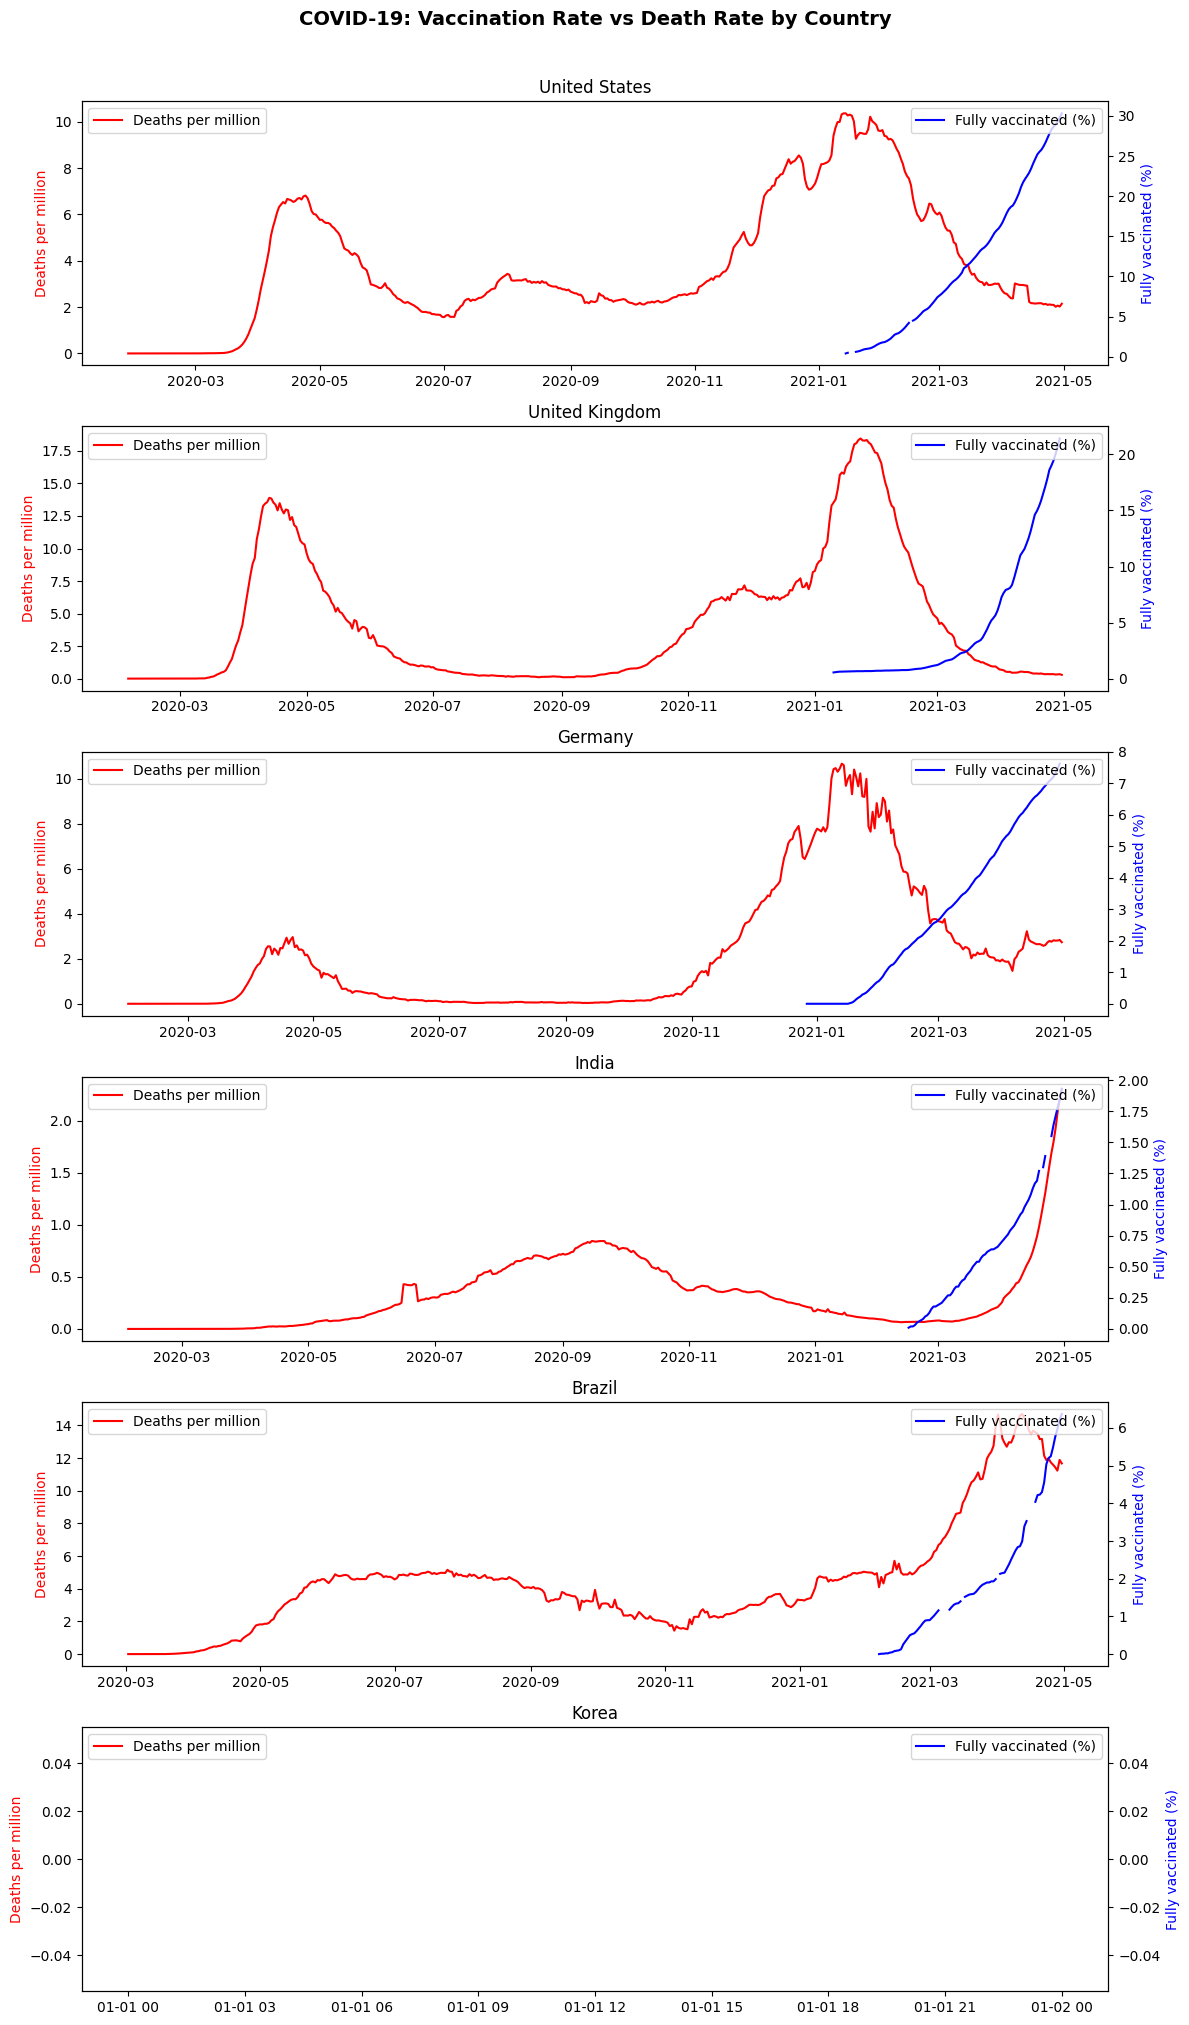

Correlation: Vaccination Rate vs Death Rate
United States       : -0.903
United Kingdom      : -0.638
Germany             : -0.865
India               : 0.917
Brazil              : 0.737


In [8]:
# convert date column to datetime format
df_filtered = df_filtered.copy()
df_filtered['date'] = pd.to_datetime(df_filtered['date'])

# plot vaccination rate vs death rate over time for each country
fig, axes = plt.subplots(len(countries), 1, figsize=(12, 20))

for i, country in enumerate(countries):
    country_df = df_filtered[df_filtered['location'] == country].sort_values('date')
    
    ax1 = axes[i]
    ax2 = ax1.twinx()  # secondary y-axis for vaccination rate
    
    # death rate on left y-axis
    ax1.plot(country_df['date'], 
             country_df['new_deaths_smoothed_per_million'], 
             color='red', label='Deaths per million', linewidth=1.5)
    
    # vaccination rate on right y-axis
    ax2.plot(country_df['date'], 
             country_df['people_fully_vaccinated_per_hundred'], 
             color='blue', label='Fully vaccinated (%)', linewidth=1.5)
    
    ax1.set_title(f'{country}', fontsize=12)
    ax1.set_ylabel('Deaths per million', color='red')
    ax2.set_ylabel('Fully vaccinated (%)', color='blue')
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.suptitle('COVID-19: Vaccination Rate vs Death Rate by Country', 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/vaccination_vs_deaths.png', dpi=150, bbox_inches='tight')
plt.show()

# calculate pearson correlation between vaccination rate and death rate per country
print("Correlation: Vaccination Rate vs Death Rate")
print("=" * 50)

for country in countries:
    country_df = df_filtered[df_filtered['location'] == country].dropna(
        subset=['people_fully_vaccinated_per_hundred', 'new_deaths_smoothed_per_million']
    )
    if len(country_df) > 10:
        corr = country_df['people_fully_vaccinated_per_hundred'].corr(
            country_df['new_deaths_smoothed_per_million']
        )
        print(f"{country:20s}: {corr:.3f}")